# LLM-ESR Supporting Extensions: Poster Content and Visualizations

This notebook finalizes the **supporting extension families** for the poster:

- **Family 1:** Adapter architecture and inductive bias
- **Family 2:** Representation, initialization, capacity, and fusion design
- **Family 3:** Self-distillation and teacher retrieval
- **Family 4:** Training objectives, augmentation, and hard negatives
- **Family 7:** Item-embedding model ablation

**Families 5 and 6 are intentionally excluded.** They will be developed later as
the two emphasized poster contributions.

The notebook has two purposes:

1. provide short, poster-ready wording for each family;
2. generate simple figures that can be exported directly into the poster.

> **Evidence note.** The project folder contains summary tables rather than the raw
> checkpoints and most underlying CSV/log files. Values below are transcribed from
> the supplied experiment summaries. Statistical units differ by study and are
> labeled where relevant.

In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

OUTPUT_DIR = Path("poster_assets") / "supporting_families"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "positive": "#2474B5",
    "negative": "#D5523A",
    "neutral": "#8A9099",
    "baseline": "#26364A",
    "accent": "#E7A22B",
    "light_blue": "#8DB8D8",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})

def save_figure(fig, stem):
    png = OUTPUT_DIR / f"{stem}.png"
    svg = OUTPUT_DIR / f"{stem}.svg"
    fig.savefig(png, bbox_inches="tight", facecolor="none", transparent=True)
    fig.savefig(svg, bbox_inches="tight", facecolor="none", transparent=True)
    print(f"Saved: {png} and {svg}")

def pp(value):
    # Convert a metric difference to percentage points.
    return value * 100

print(f"Figures will be saved to: {OUTPUT_DIR.resolve()}")

Figures will be saved to: C:\Users\AnkieF\Desktop\LLM-ESR-EXT\poster_assets\supporting_families


## Family 1 - Adapter Architecture and Inductive Bias

The previous bullet list and duplicated metric table are replaced by one compact
poster figure. The left panel shows the main activation effect on the target
long-tail metric; the right panel summarizes the best observed configuration for
each backbone.

In [28]:
family1_sasrec = pd.DataFrame([
    ("Linear\n(original)", 0.6676, 0.0019, 0.4217, 0.0023, 0.1902, 0.0060),
    ("+ Tanh",             0.6676, 0.0025, 0.4206, 0.0031, 0.1929, 0.0076),
    ("+ GELU",             0.6654, 0.0026, 0.4187, 0.0027, 0.1823, 0.0100),
    ("+ ReLU",             0.6617, 0.0037, 0.4159, 0.0035, 0.1587, 0.0115),
    ("1-layer\n(reference)", 0.6604, 0.0023, 0.4153, 0.0019, 0.1530, 0.0104),
], columns=[
    "Adapter", "Overall HR", "Overall HR std", "Overall NDCG",
    "Overall NDCG std", "Tail-Item HR", "Tail-Item HR std"
])

family1_best = pd.DataFrame([
    ("SASRec",   "Linear", "3-layer", "No",  0.4244),
    ("BERT4Rec", "GELU",   "2-layer", "No",  0.4262),
    ("GRU4Rec",  "Linear", "2-layer", "Yes", 0.3453),
], columns=["Backbone", "Activation", "Depth", "Residual", "NDCG@10"])

Saved: poster_assets\supporting_families\family1_adapter_architecture.png and poster_assets\supporting_families\family1_adapter_architecture.svg


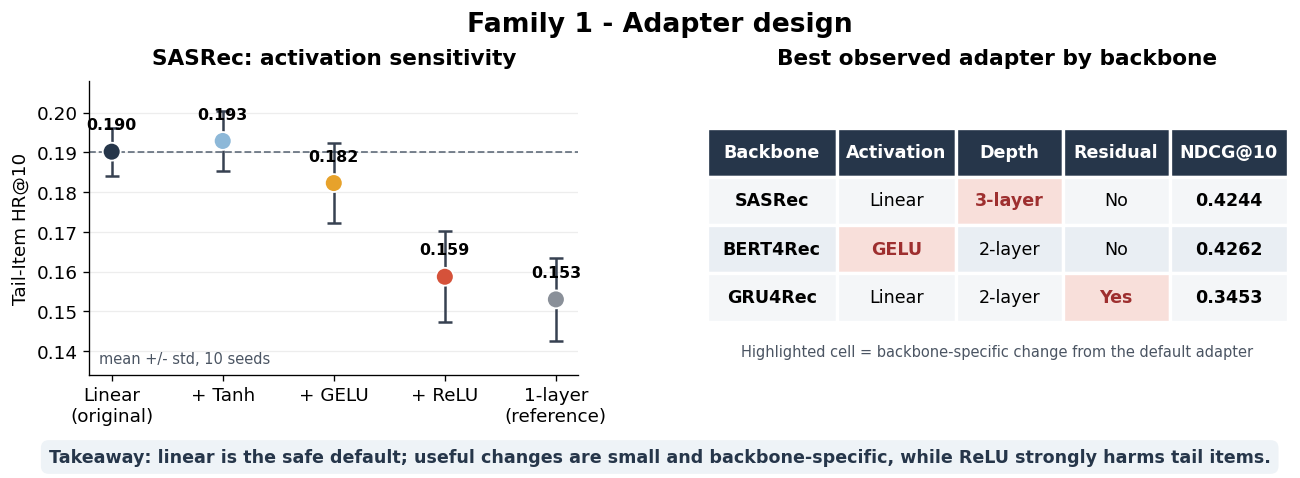

In [29]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10.8, 4.15))
gs = fig.add_gridspec(
    1, 2, width_ratios=[1.05, 1.25],
    left=0.06, right=0.985, top=0.82, bottom=0.23, wspace=0.24
)

# Panel A: focused target-metric visualization
ax = fig.add_subplot(gs[0, 0])
x = np.arange(len(family1_sasrec))
means = family1_sasrec["Tail-Item HR"].to_numpy()
stds = family1_sasrec["Tail-Item HR std"].to_numpy()
point_colors = [
    COLORS["baseline"], COLORS["light_blue"], COLORS["accent"],
    COLORS["negative"], COLORS["neutral"]
]

ax.errorbar(
    x, means, yerr=stds, fmt="none", ecolor="#374151",
    elinewidth=1.5, capsize=4, capthick=1.5, zorder=2
)
ax.scatter(
    x, means, s=115, c=point_colors, edgecolor="white",
    linewidth=1.1, zorder=3
)
ax.axhline(means[0], color=COLORS["baseline"], ls="--", lw=1.1, alpha=0.65)
ax.set_xticks(x, family1_sasrec["Adapter"])
ax.set_ylabel("Tail-Item HR@10")
ax.set_title("SASRec: activation sensitivity", fontweight="bold", pad=10)
ax.set_ylim(0.134, 0.208)
ax.grid(axis="x", visible=False)

for xi, value in zip(x, means):
    ax.text(xi, value + 0.0048, f"{value:.3f}", ha="center",
            va="bottom", fontsize=9.5, fontweight="bold")

ax.text(
    0.02, 0.04, "mean +/- std, 10 seeds",
    transform=ax.transAxes, fontsize=8.8, color="#4B5563"
)

# Panel B: compact configuration table
ax_tbl = fig.add_subplot(gs[0, 1])
ax_tbl.axis("off")
ax_tbl.set_title("Best observed adapter by backbone", fontweight="bold", pad=10)

table_text = [
    [backbone, activation, depth, residual, f"{ndcg:.4f}"]
    for backbone, activation, depth, residual, ndcg
    in family1_best.itertuples(index=False, name=None)
]
columns = ["Backbone", "Activation", "Depth", "Residual", "NDCG@10"]
table = ax_tbl.table(
    cellText=table_text, colLabels=columns, cellLoc="center", colLoc="center",
    colWidths=[0.22, 0.20, 0.18, 0.18, 0.20],
    bbox=[0.0, 0.18, 1.0, 0.66]
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(2.0)
    if row == 0:
        cell.set_facecolor(COLORS["baseline"])
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor("#F4F6F8" if row % 2 else "#E9EEF3")
        if col in (0, 4):
            cell.get_text().set_fontweight("bold")

# Highlight the architecture-specific change in each row.
for row, col in [(1, 2), (2, 1), (3, 3)]:
    table[(row, col)].set_facecolor("#F8DFDA")
    table[(row, col)].get_text().set_color("#9E2F2F")
    table[(row, col)].get_text().set_fontweight("bold")

ax_tbl.text(
    0.5, 0.08,
    "Highlighted cell = backbone-specific change from the default adapter",
    transform=ax_tbl.transAxes, ha="center", va="center",
    fontsize=8.8, color="#4B5563"
)

fig.suptitle(
    "Family 1 - Adapter design",
    fontsize=16, fontweight="bold", y=0.96
)
fig.text(
    0.5, 0.065,
    "Takeaway: linear is the safe default; useful changes are small and backbone-specific, while ReLU strongly harms tail items.",
    ha="center", va="center", fontsize=10.5, fontweight="bold", color="#26364A",
    bbox=dict(boxstyle="round,pad=0.45", facecolor="#EEF3F7", edgecolor="none")
)

save_figure(fig, "family1_adapter_architecture")
plt.show()

**Poster takeaway:** Linear adapters remain the reliable default. A deeper linear
adapter helps SASRec slightly, a residual path helps GRU4Rec, and ReLU is the
clearest unsafe choice because its damage concentrates on tail items.

## Family 2 - Representation and Fusion

- **C1 Collab adapter:** extra projection - **harmful**
- **C2-a PCA alternative:** linear AE ~ PCA; nonlinear AE **worse**
- **C2-b Hidden size 128:** **no capacity gain**
- **C3 LoRA unfreezing:** tail overfitting; higher rank **worse**
- **C4 Popularity gate:** monotonic **harmful**; free gate **neutral**

In [30]:
family2 = pd.DataFrame([
    ("C1: Collab adapter", "d=16", -0.0258, True),
    ("C1: Collab adapter", "d=32", -0.0290, True),
    ("C1: Collab adapter", "d=128", -0.0353, True),
    ("C3: LoRA", "rank 8", -0.0108, True),
    ("C3: LoRA", "rank 32", -0.0230, True),
    ("C4: Fusion gate", "popularity gate", -0.0032, True),
    ("C4: Fusion gate", "free per-item gate", 0.0013, False),
    ("C2-a: PCA alternative", "linear AE init", -0.0014, False),
    ("C2-a: PCA alternative", "nonlinear AE init", -0.0083, True),
    ("C2-b: Capacity", "hidden size 128", -0.0017, False),
], columns=["Experiment", "Variant", "Delta Overall HR@10", "Significant"])

family2["Delta Overall HR (pp)"] = pp(family2["Delta Overall HR@10"])
family2

,Experiment,Variant,Delta Overall HR@10,Significant,Delta Overall HR (pp)
0,C1: Collab adapter,d=16,-0.0258,True,-2.58
1,C1: Collab adapter,d=32,-0.0290,True,-2.90
2,C1: Collab adapter,d=128,-0.0353,True,-3.53
3,C3: LoRA,rank 8,-0.0108,True,-1.08
4,C3: LoRA,rank 32,-0.0230,True,-2.30
5,C4: Fusion gate,popularity gate,-0.0032,True,-0.32
6,C4: Fusion gate,free per-item gate,0.0013,False,0.13
7,C2-a: PCA alternative,linear AE init,-0.0014,False,-0.14
8,C2-a: PCA alternative,nonlinear AE init,-0.0083,True,-0.83
9,C2-b: Capacity,hidden size 128,-0.0017,False,-0.17


Saved: poster_assets\supporting_families\family2_representation_fusion.png and poster_assets\supporting_families\family2_representation_fusion.svg


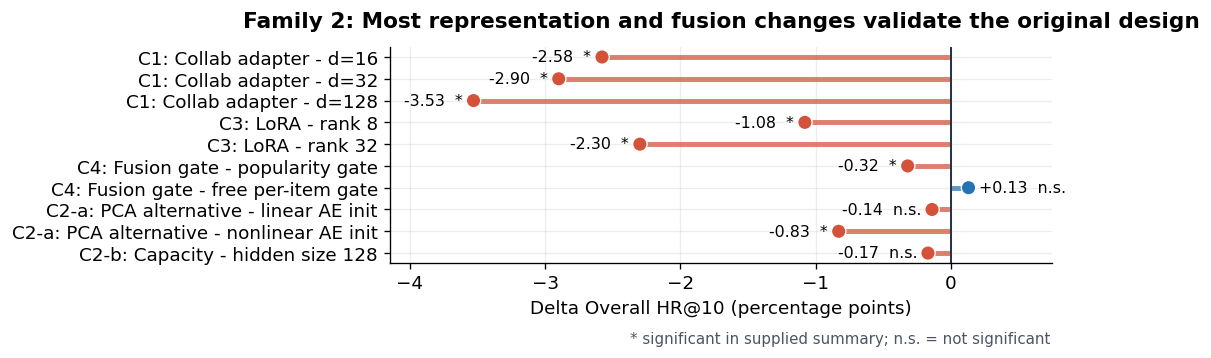

In [31]:
plot2 = family2.copy()
plot2["Label"] = plot2["Experiment"] + " - " + plot2["Variant"]
plot2 = plot2.iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 3))
values = plot2["Delta Overall HR (pp)"].to_numpy()
colors = [COLORS["positive"] if v > 0.025 else COLORS["negative"] if v < -0.025 else COLORS["neutral"] for v in values]
y = np.arange(len(plot2))

ax.hlines(y, 0, values, color=colors, lw=3, alpha=0.72)
ax.scatter(values, y, color=colors, s=75, zorder=3, edgecolor="white", linewidth=0.8)
ax.axvline(0, color=COLORS["baseline"], lw=1.2)
ax.set_yticks(y, plot2["Label"])
ax.set_xlabel("Delta Overall HR@10 (percentage points)")
ax.set_title("Family 2: Most representation and fusion changes validate the original design",
             fontweight="bold", pad=12)

for yi, value, sig in zip(y, values, plot2["Significant"]):
    marker = "*" if sig else "n.s."
    ax.text(value - 0.08 if value < 0 else value + 0.08, yi,
            f"{value:+.2f}  {marker}", va="center",
            ha="right" if value < 0 else "left", fontsize=9.5)

ax.set_xlim(-4.15, 0.75)
fig.text(
    0.98, 0.015,
    "* significant in supplied summary; n.s. = not significant",
    ha="right", va="bottom", fontsize=9, color="#4B5563"
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
save_figure(fig, "family2_representation_fusion")
plt.show()

**Takeaway:** PCA initialization, frozen semantics, 64 dimensions, and ungated
fusion remain the strongest defaults.

## Family 3 - Self-Distillation Variants

- **Pooling / retrieval plot:** weighted pooling, stochastic top-10 sampling, and hybrid collaborative re-ranking
- **Teacher-count plot:** top-k and stochastic retrieval with **k = 5, 10, 20, 30**

In [32]:
family3_variants = pd.DataFrame([
    ("Baseline:\nmean + \ntop-10", 0.4222),
    ("Weighted\npooling", 0.4171),
    ("Stochastic\ntop-10", 0.4216),
    ("Hybrid\nretrieval", 0.4220),
], columns=["Variant", "Tail-User NDCG@10"])
family3_variants["Delta vs baseline (pp)"] = pp(family3_variants["Tail-User NDCG@10"] - 0.4222)

family3_counts = pd.DataFrame([
    ("Top-k", 5, 0.4221),
    ("Top-k", 10, 0.4222),
    ("Top-k", 20, 0.4210),
    ("Top-k", 30, 0.4208),
    ("Stochastic", 5, 0.4208),
    ("Stochastic", 10, 0.4216),
    ("Stochastic", 20, 0.4198),
    ("Stochastic", 30, 0.4211),
], columns=["Method", "Teachers (k)", "Tail-User NDCG@10"])

display(family3_variants)
display(family3_counts)

,Variant,Tail-User NDCG@10,Delta vs baseline (pp)
0,Baseline:\nmean + \ntop-10,0.4222,0.00
1,Weighted\npooling,0.4171,-0.51
2,Stochastic\ntop-10,0.4216,-0.06
3,Hybrid\nretrieval,0.4220,-0.02


,Method,Teachers (k),Tail-User NDCG@10
0,Top-k,5,0.4221
1,Top-k,10,0.4222
2,Top-k,20,0.4210
3,Top-k,30,0.4208
4,Stochastic,5,0.4208
5,Stochastic,10,0.4216
6,Stochastic,20,0.4198
7,Stochastic,30,0.4211


Saved: poster_assets\supporting_families\family3_self_distillation.png and poster_assets\supporting_families\family3_self_distillation.svg


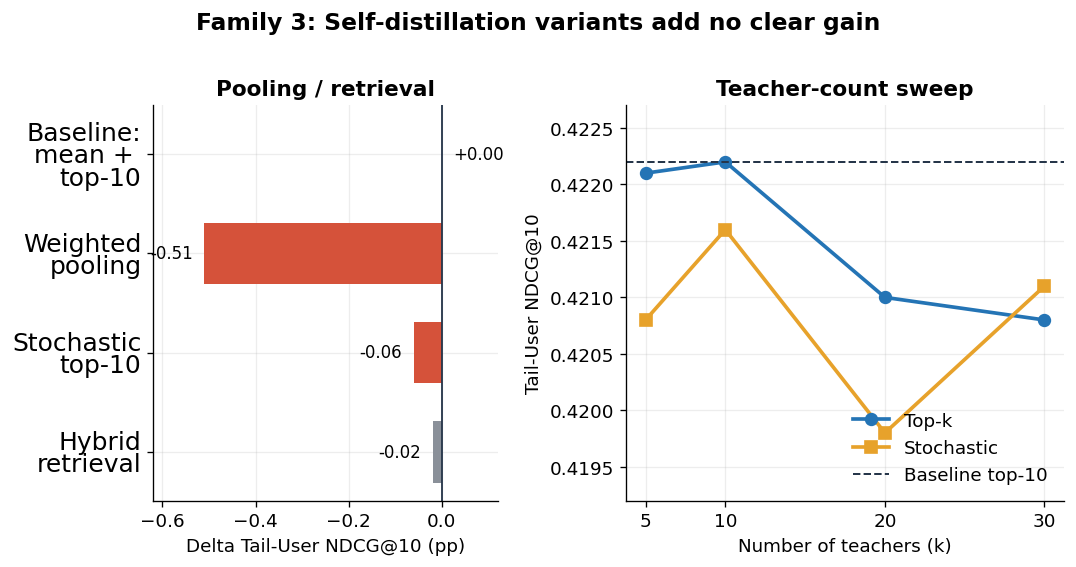

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(9.1, 4.65), gridspec_kw={"width_ratios": [0.88, 1.12]})

# Panel A: aggregation/retrieval changes
sub = family3_variants.iloc[::-1]
values = sub["Delta vs baseline (pp)"].to_numpy()
colors = [COLORS["baseline"] if "Baseline" in name else
          COLORS["negative"] if value < -0.025 else COLORS["neutral"]
          for name, value in zip(sub["Variant"], values)]
y = np.arange(len(sub))
axes[0].barh(y, values, color=colors, height=0.62)
axes[0].axvline(0, color=COLORS["baseline"], lw=1.1)
axes[0].set_yticks(y, sub["Variant"], fontsize=15, linespacing=0.9)
axes[0].set_xlabel("Delta Tail-User NDCG@10 (pp)")
axes[0].set_title("Pooling / retrieval", fontweight="bold")
for yi, value in zip(y, values):
    axes[0].text(value - 0.025 if value < 0 else value + 0.025, yi,
                 f"{value:+.2f}", va="center",
                 ha="right" if value < 0 else "left", fontsize=10)
axes[0].set_xlim(-0.62, 0.12)

# Panel B: teacher count
for method, color, marker in [
    ("Top-k", COLORS["positive"], "o"),
    ("Stochastic", COLORS["accent"], "s"),
]:
    part = family3_counts[family3_counts["Method"] == method]
    axes[1].plot(part["Teachers (k)"], part["Tail-User NDCG@10"],
                 marker=marker, lw=2.2, ms=7, color=color, label=method)
axes[1].axhline(0.4222, color=COLORS["baseline"], lw=1.2, ls="--",
                label="Baseline top-10")
axes[1].set_xticks([5, 10, 20, 30])
axes[1].set_xlabel("Number of teachers (k)")
axes[1].set_ylabel("Tail-User NDCG@10")
axes[1].set_title("Teacher-count sweep", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].set_ylim(0.4192, 0.4227)

fig.suptitle("Family 3: Self-distillation variants add no clear gain",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
save_figure(fig, "family3_self_distillation")
plt.show()

**Takeaway:** None beats the original mean-pooled top-10 teachers.

## Family 4 - Training Strategy Experiments

### What we changed

- Replaced random negatives with **LLM-similar hard negatives**.
- Replaced the original loss with **in-batch sampled-softmax**.
- Expanded each sequence into **all training prefixes**.

### Poster conclusion

> **Stronger-looking training signals do not break the performance ceiling.**
> LLM-similar negatives are often false negatives, all-prefix augmentation creates
> train-test mismatch, and sampled-softmax produces an extreme tail-versus-overall
> trade-off rather than a general improvement.

In [34]:
hard_negative = pd.DataFrame([
    (0.00, 0.6725, 0.4226),
    (0.25, 0.6491, 0.4057),
    (0.50, 0.6333, 0.3913),
    (1.00, 0.4641, 0.2624),
], columns=["Hard-negative ratio", "Overall HR@10", "Overall NDCG@10"])

training_strategy = pd.DataFrame([
    ("All-prefix augmentation", -0.0242, -0.0562),
    ("In-batch sampled-softmax", -0.1934, +0.2020),
], columns=["Strategy", "Delta Overall HR@10", "Delta Tail-Item HR@10"])

display(hard_negative)
display(training_strategy)

,Hard-negative ratio,Overall HR@10,Overall NDCG@10
0,0.00,0.6725,0.4226
1,0.25,0.6491,0.4057
2,0.50,0.6333,0.3913
3,1.00,0.4641,0.2624


,Strategy,Delta Overall HR@10,Delta Tail-Item HR@10
0,All-prefix augmentation,-0.0242,-0.0562
1,In-batch sampled-softmax,-0.1934,0.2020


Saved: poster_assets\supporting_families\family4_training_strategies.png and poster_assets\supporting_families\family4_training_strategies.svg


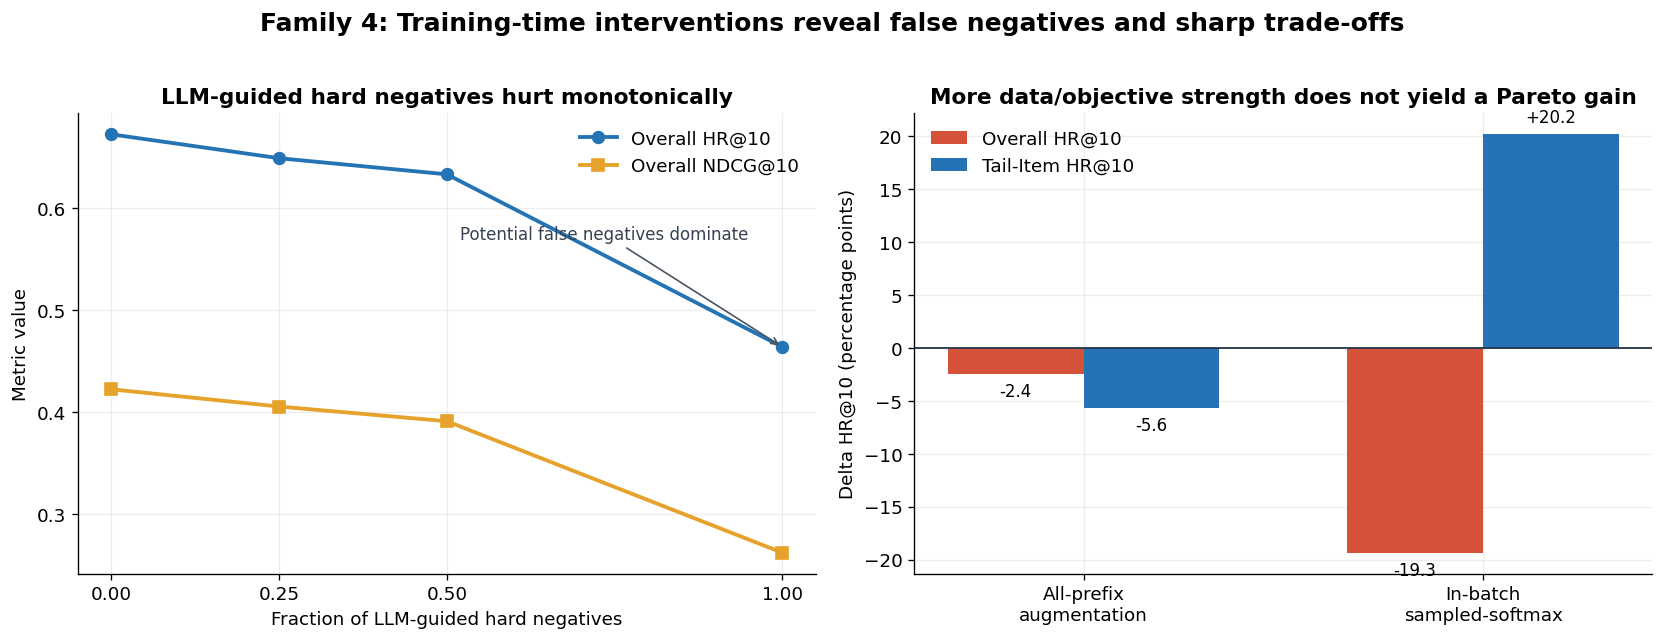

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# Panel A: hard-negative ratio sweep
axes[0].plot(hard_negative["Hard-negative ratio"], hard_negative["Overall HR@10"],
             marker="o", ms=7, lw=2.3, color=COLORS["positive"], label="Overall HR@10")
axes[0].plot(hard_negative["Hard-negative ratio"], hard_negative["Overall NDCG@10"],
             marker="s", ms=7, lw=2.3, color=COLORS["accent"], label="Overall NDCG@10")
axes[0].set_xlabel("Fraction of LLM-guided hard negatives")
axes[0].set_ylabel("Metric value")
axes[0].set_title("LLM-guided hard negatives hurt monotonically", fontweight="bold")
axes[0].set_xticks([0, 0.25, 0.50, 1.00])
axes[0].legend()
axes[0].annotate(
    "Potential false negatives dominate",
    xy=(1.0, 0.4641), xytext=(0.52, 0.57),
    arrowprops=dict(arrowstyle="->", color="#4B5563"),
    fontsize=10, color="#374151"
)

# Panel B: overall-tail trade-offs
x = np.arange(len(training_strategy))
width = 0.34
overall = pp(training_strategy["Delta Overall HR@10"])
tail = pp(training_strategy["Delta Tail-Item HR@10"])
axes[1].bar(x - width/2, overall, width, color=COLORS["negative"], label="Overall HR@10")
axes[1].bar(x + width/2, tail, width, color=COLORS["positive"],
            label="Tail-Item HR@10")
axes[1].axhline(0, color=COLORS["baseline"], lw=1.1)
axes[1].set_xticks(x, ["All-prefix\naugmentation", "In-batch\nsampled-softmax"])
axes[1].set_ylabel("Delta HR@10 (percentage points)")
axes[1].set_title("More data/objective strength does not yield a Pareto gain", fontweight="bold")
axes[1].legend()

for xi, ov, tv in zip(x, overall, tail):
    axes[1].text(xi - width/2, ov - 0.8 if ov < 0 else ov + 0.8,
                 f"{ov:+.1f}", ha="center",
                 va="top" if ov < 0 else "bottom", fontsize=10)
    axes[1].text(xi + width/2, tv - 0.8 if tv < 0 else tv + 0.8,
                 f"{tv:+.1f}", ha="center",
                 va="top" if tv < 0 else "bottom", fontsize=10)

fig.suptitle("Family 4: Training-time interventions reveal false negatives and sharp trade-offs",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
save_figure(fig, "family4_training_strategies")
plt.show()

### Interpretation for the poster

- **Hard negatives:** increasing the semantic-hard-negative ratio causes monotonic
  degradation. Similar content is often something the user may also like, so the
  method labels plausible positives as negatives.
- **All-prefix augmentation:** approximately ten times more training examples still
  lowers both overall and tail accuracy, consistent with a shift away from the
  full-sequence evaluation distribution.
- **Sampled-softmax:** tail-item HR rises dramatically, but overall HR collapses.
  This is evidence of a popularity-reweighting trade-off, not better recommendation
  quality overall.

## Family 7 - Item-Embedding Model Ablation

- Replaced only the item encoder: **word2vec, ada-002, 3-small, 3-large, Gemini**
- User retrieval and the remaining LLM-ESR pipeline were fixed

**Caveat:** exploratory seed-42 result on the separately preprocessed Yelp dataset.

In [36]:
family7 = pd.DataFrame([
    ("word2vec", "Non-LLM", 0.6039, 0.3285, 0.8949),
    ("ada-002", "Original", 0.5988, 0.3226, 0.8912),
    ("3-small", "Modern LLM", 0.6247, 0.3321, 0.8988),
    ("3-large", "Modern LLM", 0.6570, 0.3449, 0.9007),
    ("Gemini", "Modern LLM", 0.7799, 0.4057, 0.9228),
], columns=["Encoder", "Type", "Tail-Item HR@10", "Tail-Item NDCG@10", "Overall HR@10"])
family7

,Encoder,Type,Tail-Item HR@10,Tail-Item NDCG@10,Overall HR@10
0,word2vec,Non-LLM,0.6039,0.3285,0.8949
1,ada-002,Original,0.5988,0.3226,0.8912
2,3-small,Modern LLM,0.6247,0.3321,0.8988
3,3-large,Modern LLM,0.6570,0.3449,0.9007
4,Gemini,Modern LLM,0.7799,0.4057,0.9228


Saved: poster_assets\supporting_families\family7_embedding_models.png and poster_assets\supporting_families\family7_embedding_models.svg


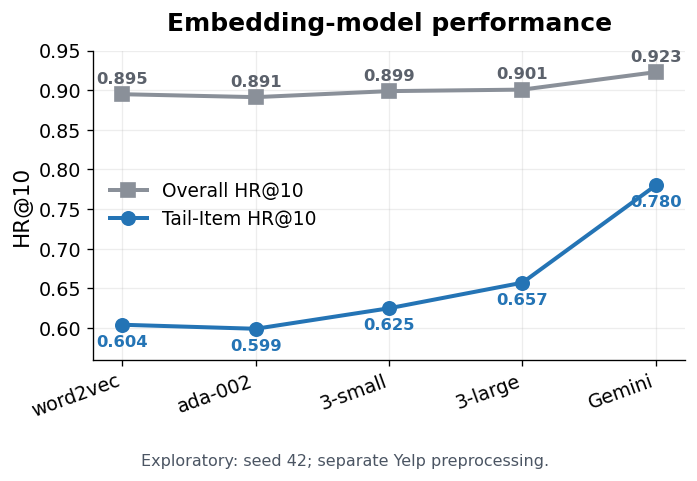

In [40]:
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(family7))
tail_hr = family7["Tail-Item HR@10"].to_numpy()
overall_hr = family7["Overall HR@10"].to_numpy()

ax.plot(
    x, overall_hr, marker="s", ms=8, lw=2.4,
    color=COLORS["neutral"], label="Overall HR@10", zorder=3
)
ax.plot(
    x, tail_hr, marker="o", ms=8, lw=2.4,
    color=COLORS["positive"], label="Tail-Item HR@10", zorder=3
)

ax.set_xticks(x, family7["Encoder"], rotation=20, ha="right", fontsize=11.5)
ax.tick_params(axis="y", labelsize=11.5)
ax.set_ylabel("HR@10", fontsize=13)
ax.set_title("Embedding-model performance",
             fontweight="bold", fontsize=15, pad=12)
ax.legend(loc="center left", fontsize=11.2)
ax.set_ylim(0.56, 0.95)
ax.set_yticks(np.arange(0.60, 0.96, 0.05))
ax.margins(x=0.055)

for xi, value in zip(x, overall_hr):
    ax.text(
        xi, value + 0.010, f"{value:.3f}",
        ha="center", va="bottom", fontsize=9.8,
        fontweight="bold", color="#5B616B"
    )

for xi, value in zip(x, tail_hr):
    ax.text(
        xi, value - 0.012, f"{value:.3f}",
        ha="center", va="top", fontsize=9.8,
        fontweight="bold", color=COLORS["positive"]
    )

fig.text(
    0.5, 0.012,
    "Exploratory: seed 42; separate Yelp preprocessing.",
    ha="center", fontsize=9.6, color="#4B5563"
)
fig.tight_layout(rect=[0.01, 0.065, 1, 1])
save_figure(fig, "family7_embedding_models")
plt.show()

**Takeaway:** Modern embeddings substantially improve tail-item accuracy, while
overall accuracy changes much less; ada-002 does not beat word2vec.

## Final Poster-Ready Summary

| Family | Recommended visual | One-line conclusion |
|---|---|---|
| **1. Adapter architecture** | Three-panel delta-NDCG bar chart | Linear is the safest default; SASRec benefits slightly from three linear layers and GRU4Rec from a residual path. |
| **2. Representation and fusion** | Compact verdict cards plus delta-HR lollipop plot | PCA, freezing, and the original capacity are load-bearing or already near-optimal. |
| **3. Self-distillation** | Variant bars plus teacher-count lines | Alternative pooling and retrieval strategies do not improve tail users. |
| **4. Training strategies** | Hard-negative curve plus overall-tail trade-off bars | Stronger training signals introduce false negatives, mismatch, or severe trade-offs. |
| **7. Embedding ablation** | Single actual HR@10 comparison chart | Modern embedding quality drives long-tail gains; ada-002 itself does not beat word2vec. |

### Suggested space allocation

- Family 1: medium supporting panel
- Family 2: compact experiment-card panel
- Family 3: compact supporting panel
- Family 4: medium negative-results panel
- Family 7: medium supporting panel with a prominent caveat badge

Families 5 and 6 should later receive substantially more space than any individual
family above.

### Generated assets

Running this notebook exports each figure as both PNG and editable SVG under:

`poster_assets/supporting_families/`

## Source Notes

- Family 1:
  `10-SEED UPDATE.md`, `ADAPTER_ANALYSIS_EN.md`,
  `TTEST_ANALYSIS_EN.md`, `extension-log-0618.md`
- Family 2:
  `extension-log-0618.md`
- Family 3:
  `self-distillation.md`, `sd_teacher_alter.md`,
  `sd_hybrid_retrieval.md`
- Family 4:
  `HARDNEG_EXTENSION_EN.md`, `extension-log-0618.md`
- Family 7:
  `embedding_ablation.md`

The notebook intentionally avoids claims requiring missing raw artifacts such as
`STATS_10seeds.txt`, `embedding_ablation.csv`, and the referenced `SUMMARY_*.txt`
files.